# Player Similarity via Learnable Identity Embeddings

## Building on the GNN Pass Recipient Prediction Model

This notebook implements the **Future Work** described in the project README:

1. **Link freeze-frame positions to StatsBomb lineup data** to identify players
2. **Add per-player learnable embeddings** trained end-to-end with pass prediction
3. **Compute player-to-player similarity** from the learned embeddings

### Key Insight
The 360 freeze frames contain only spatial data (`location`, `teammate`, `actor`, `keeper`) — no player IDs.
We recover identities by:
- **Passer**: always known via event `player.id` + freeze-frame `actor` flag
- **Recipient**: known for completed passes via event `pass.recipient.id` + proximity to `pass.end_location`
- **Goalkeepers**: identified via lineup data + `keeper` flag + `teammate` flag

All other nodes receive a shared `UNKNOWN` token. The model learns a **per-player embedding** that
captures individual passing/receiving tendencies, jointly optimized with the spatial GAT.

In [33]:
import json
import os
import glob
import math
import time
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv
from torch_geometric.utils import softmax as pyg_softmax
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity

print(f"PyTorch version: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.9.1
Using device: cpu


## 1. Constants & Data Paths

In [34]:
DATA_DIR = os.path.join("..", "data")
EVENTS_DIR = os.path.join(DATA_DIR, "events")
THREE_SIXTY_DIR = os.path.join(DATA_DIR, "three-sixty")
LINEUPS_DIR = os.path.join(DATA_DIR, "lineups")

SB_PITCH_LENGTH = 120.0
SB_PITCH_WIDTH = 80.0

NUM_NODE_FEATURES = 6  # spatial features (is_keeper removed to avoid embedding bias)
PLAYER_EMBED_DIM = 32
HIDDEN_DIM = 64
GAT_HEADS = 4
DROPOUT = 0.2
BATCH_SIZE = 512
NUM_EPOCHS = 15
LR = 1e-3
WEIGHT_DECAY = 1e-4
ID_MASK_PROB = 0.85  # during training, randomly mask player IDs to prevent memorization

UNKNOWN_PLAYER_ID = 0  # reserved for unidentified players

three_sixty_files = sorted(glob.glob(os.path.join(THREE_SIXTY_DIR, "*.json")))
match_ids_with_360 = [os.path.splitext(os.path.basename(f))[0] for f in three_sixty_files]
print(f"Matches with 360 data: {len(match_ids_with_360)}")


def sb_to_normalized(x: float, y: float) -> tuple[float, float]:
    return x / SB_PITCH_LENGTH, y / SB_PITCH_WIDTH

Matches with 360 data: 326


## 2. Load Match Data with Lineups

For each match we load:
- **Events** — pass events with passer/recipient player IDs
- **360 frames** — freeze-frame snapshots indexed by event UUID
- **Lineups** — full squad lists with player IDs, used to identify goalkeepers

In [35]:
def load_match_data(match_id: str):
    """Load events, 360 frames, and lineups for a single match."""
    try:
        with open(os.path.join(EVENTS_DIR, f"{match_id}.json")) as f:
            events = json.load(f)
        with open(os.path.join(THREE_SIXTY_DIR, f"{match_id}.json")) as f:
            three_sixty = json.load(f)
        with open(os.path.join(LINEUPS_DIR, f"{match_id}.json")) as f:
            lineups = json.load(f)
    except (json.JSONDecodeError, FileNotFoundError) as e:
        print(f"  Skipping match {match_id}: {e.__class__.__name__}")
        return None

    freeze_frames = {item["event_uuid"]: item for item in three_sixty}

    # Build keeper lookup: team_id → set of player_ids who are GKs
    # We identify GKs from any event where the player's position is Goalkeeper
    keeper_ids = set()
    for evt in events:
        pos = evt.get("position", {})
        if pos.get("name") == "Goalkeeper":
            keeper_ids.add(evt["player"]["id"])

    return events, freeze_frames, lineups, keeper_ids


# Quick test
result = load_match_data(match_ids_with_360[0])
if result:
    events, frames, lineups, keeper_ids = result
    print(f"Match {match_ids_with_360[0]}: {len(events)} events, "
          f"{len(frames)} 360 frames, keepers: {keeper_ids}")
    for team in lineups:
        print(f"  Team: {team['team_name']} ({len(team['lineup'])} players)")

Match 3788741: 3803 events, 3370 360 frames, keepers: {7036, 30357}
  Team: Italy (23 players)
  Team: Turkey (23 players)


## 3. Build Player Vocabulary

We scan all events across all 360-data matches to build a mapping from StatsBomb `player_id` → vocabulary index.
Index 0 is reserved for `UNKNOWN` (players we cannot identify in a freeze frame).

In [36]:
player_id_to_name: dict[int, str] = {}

for match_id in tqdm(match_ids_with_360, desc="Scanning player IDs"):
    try:
        with open(os.path.join(EVENTS_DIR, f"{match_id}.json")) as f:
            events = json.load(f)
    except (json.JSONDecodeError, FileNotFoundError):
        continue
    for evt in events:
        p = evt.get("player")
        if p:
            player_id_to_name[p["id"]] = p["name"]

# Build vocab: 0 = UNKNOWN, then sorted player IDs
sorted_player_ids = sorted(player_id_to_name.keys())
player_to_vocab = {pid: idx + 1 for idx, pid in enumerate(sorted_player_ids)}
vocab_to_player = {idx + 1: pid for idx, pid in enumerate(sorted_player_ids)}
vocab_to_player[UNKNOWN_PLAYER_ID] = None
VOCAB_SIZE = len(player_to_vocab) + 1  # +1 for UNKNOWN at index 0

print(f"Unique players found: {len(player_to_vocab)}")
print(f"Vocabulary size (incl. UNKNOWN): {VOCAB_SIZE}")

Scanning player IDs: 100%|██████████| 326/326 [00:14<00:00, 22.08it/s]

Unique players found: 2419
Vocabulary size (incl. UNKNOWN): 2420


In [60]:
player_to_vocab

{2941: 1,
 2954: 2,
 2972: 3,
 2988: 4,
 2989: 5,
 2995: 6,
 2999: 7,
 3009: 8,
 3026: 9,
 3034: 10,
 3042: 11,
 3043: 12,
 3053: 13,
 3063: 14,
 3067: 15,
 3076: 16,
 3077: 17,
 3083: 18,
 3086: 19,
 3089: 20,
 3090: 21,
 3091: 22,
 3097: 23,
 3099: 24,
 3117: 25,
 3135: 26,
 3141: 27,
 3153: 28,
 3166: 29,
 3167: 30,
 3168: 31,
 3176: 32,
 3193: 33,
 3196: 34,
 3202: 35,
 3205: 36,
 3230: 37,
 3233: 38,
 3240: 39,
 3244: 40,
 3245: 41,
 3247: 42,
 3264: 43,
 3265: 44,
 3280: 45,
 3281: 46,
 3289: 47,
 3295: 48,
 3300: 49,
 3306: 50,
 3308: 51,
 3311: 52,
 3318: 53,
 3321: 54,
 3323: 55,
 3325: 56,
 3336: 57,
 3347: 58,
 3377: 59,
 3378: 60,
 3380: 61,
 3382: 62,
 3404: 63,
 3428: 64,
 3436: 65,
 3441: 66,
 3450: 67,
 3457: 68,
 3468: 69,
 3470: 70,
 3471: 71,
 3477: 72,
 3488: 73,
 3493: 74,
 3499: 75,
 3500: 76,
 3509: 77,
 3512: 78,
 3517: 79,
 3530: 80,
 3532: 81,
 3533: 82,
 3543: 83,
 3551: 84,
 3557: 85,
 3567: 86,
 3570: 87,
 3575: 88,
 3581: 89,
 3593: 90,
 3604: 91,
 3616: 9

## 4. Enhanced Graph Construction

Each graph now carries an additional `player_ids` tensor (one vocab index per node).

**Identity resolution strategy per node:**
| Condition | Identified via | Player ID source |
|---|---|---|
| `actor == True` | Freeze-frame flag | Event `player.id` |
| Teammate closest to `pass.end_location` | Spatial matching | Event `pass.recipient.id` |
| `keeper == True` | Freeze-frame flag + match keeper set | Lineup / event positions |
| All others | — | `UNKNOWN` (index 0) |

In [37]:
def identify_keeper_for_side(event, lineups, keeper_ids, is_teammate_side: bool):
    """Return the player_id of the keeper on the given side, or None."""
    passer_team_id = event["team"]["id"]
    for team_data in lineups:
        team_id = team_data["team_id"]
        is_passer_team = (team_id == passer_team_id)
        if is_passer_team == is_teammate_side:
            for p in team_data["lineup"]:
                if p["player_id"] in keeper_ids:
                    return p["player_id"]
    return None


def build_pass_graph_with_ids(event, freeze_frame, lineups, keeper_ids):
    """Build a PyG Data object with player identity information."""
    pass_data = event["pass"]
    freeze = freeze_frame.get("freeze_frame", [])

    if len(freeze) < 3:
        return None

    origin_x, origin_y = event["location"]
    end_x, end_y = pass_data["end_location"]
    ox_n, oy_n = sb_to_normalized(origin_x, origin_y)
    ex_n, ey_n = sb_to_normalized(end_x, end_y)

    passer_pid = event["player"]["id"]
    recipient_pid = pass_data.get("recipient", {}).get("id")

    # Pre-resolve keeper IDs for each side
    teammate_keeper_pid = identify_keeper_for_side(event, lineups, keeper_ids, True)
    opponent_keeper_pid = identify_keeper_for_side(event, lineups, keeper_ids, False)

    node_features = []
    is_candidate = []
    player_vocab_ids = []
    min_dist_to_end = float("inf")
    recipient_idx = -1

    for i, player in enumerate(freeze):
        px, py = player["location"]
        px_n, py_n = sb_to_normalized(px, py)

        teammate = float(player.get("teammate", False))
        actor = float(player.get("actor", False))
        keeper = bool(player.get("keeper", False))

        dx = px_n - ox_n
        dy = py_n - oy_n
        dist_to_ball = math.sqrt(dx * dx + dy * dy)
        angle_to_ball = math.atan2(dy, dx) / math.pi

        node_features.append([
            px_n, py_n, teammate, actor,
            dist_to_ball, angle_to_ball,
        ])

        # --- Identify this node's player ID ---
        if player.get("actor", False):
            pid = passer_pid
        elif keeper:
            if player.get("teammate", False):
                pid = teammate_keeper_pid
            else:
                pid = opponent_keeper_pid
        else:
            pid = None  # will try to resolve as recipient below

        is_candidate_node = bool(teammate) and not bool(player.get("actor", False))
        is_candidate.append(is_candidate_node)

        if is_candidate_node:
            dx_end = px_n - ex_n
            dy_end = py_n - ey_n
            dist_to_end = math.sqrt(dx_end * dx_end + dy_end * dy_end)
            if dist_to_end < min_dist_to_end:
                min_dist_to_end = dist_to_end
                recipient_idx = i

        player_vocab_ids.append(pid)

    if recipient_idx == -1:
        return None

    # Assign recipient identity to the matched node (if not already set)
    if player_vocab_ids[recipient_idx] is None and recipient_pid is not None:
        player_vocab_ids[recipient_idx] = recipient_pid

    # Convert player IDs to vocab indices
    vocab_ids = []
    for pid in player_vocab_ids:
        if pid is not None and pid in player_to_vocab:
            vocab_ids.append(player_to_vocab[pid])
        else:
            vocab_ids.append(UNKNOWN_PLAYER_ID)

    n = len(freeze)
    src = [i for i in range(n) for j in range(n) if i != j]
    dst = [j for i in range(n) for j in range(n) if i != j]

    x = torch.tensor(node_features, dtype=torch.float)
    edge_index = torch.tensor([src, dst], dtype=torch.long)
    candidate_mask = torch.tensor(is_candidate, dtype=torch.bool)
    y = torch.tensor(recipient_idx, dtype=torch.long)
    p_ids = torch.tensor(vocab_ids, dtype=torch.long)

    data = Data(x=x, edge_index=edge_index, y=y)
    data.candidate_mask = candidate_mask
    data.num_candidates = int(candidate_mask.sum().item())
    data.player_ids = p_ids

    return data

## 5. Build Full Dataset

In [38]:
all_graphs = []
stats = defaultdict(int)

for match_id in tqdm(match_ids_with_360, desc="Processing matches"):
    result = load_match_data(match_id)
    if result is None:
        stats["bad_json"] += 1
        continue
    events, freeze_frames, lineups, keeper_ids = result

    for event in events:
        if event.get("type", {}).get("name") != "Pass":
            continue
        if "pass" not in event or "recipient" not in event["pass"]:
            stats["no_recipient"] += 1
            continue
        if "outcome" in event["pass"]:
            stats["incomplete"] += 1
            continue
        if event["id"] not in freeze_frames:
            stats["no_360"] += 1
            continue

        graph = build_pass_graph_with_ids(
            event, freeze_frames[event["id"]], lineups, keeper_ids
        )
        if graph is not None:
            all_graphs.append(graph)
            stats["success"] += 1
        else:
            stats["build_failed"] += 1

print(f"\n=== Dataset Statistics ===")
print(f"Graphs built: {stats['success']:,}")
print(f"Incomplete passes filtered: {stats['incomplete']:,}")
print(f"No recipient: {stats['no_recipient']:,}")
print(f"No 360 data: {stats['no_360']:,}")
print(f"Build failures: {stats['build_failed']:,}")
print(f"Bad JSON: {stats['bad_json']:,}")
print(f"\nTotal graphs: {len(all_graphs):,}")

Processing matches:  22%|██▏       | 72/326 [00:20<00:29,  8.51it/s]

  Skipping match 3835338: JSONDecodeError


Processing matches:  23%|██▎       | 76/326 [00:20<00:30,  8.31it/s]

  Skipping match 3835342: JSONDecodeError


Processing matches:  25%|██▍       | 81/326 [00:24<01:37,  2.52it/s]

  Skipping match 3845506: JSONDecodeError


Processing matches: 100%|██████████| 326/326 [01:32<00:00,  3.53it/s]


=== Dataset Statistics ===
Graphs built: 227,513
Incomplete passes filtered: 43,455
No recipient: 20,557
No 360 data: 40,309
Build failures: 148
Bad JSON: 3

Total graphs: 227,513


In [62]:
all_graphs

[Data(x=[10, 6], edge_index=[2, 90], y=8, candidate_mask=[10], num_candidates=3, player_ids=[10]),
 Data(x=[18, 6], edge_index=[2, 306], y=14, candidate_mask=[18], num_candidates=9, player_ids=[18]),
 Data(x=[15, 6], edge_index=[2, 210], y=3, candidate_mask=[15], num_candidates=7, player_ids=[15]),
 Data(x=[6, 6], edge_index=[2, 30], y=1, candidate_mask=[6], num_candidates=4, player_ids=[6]),
 Data(x=[10, 6], edge_index=[2, 90], y=2, candidate_mask=[10], num_candidates=6, player_ids=[10]),
 Data(x=[12, 6], edge_index=[2, 132], y=1, candidate_mask=[12], num_candidates=6, player_ids=[12]),
 Data(x=[12, 6], edge_index=[2, 132], y=0, candidate_mask=[12], num_candidates=6, player_ids=[12]),
 Data(x=[12, 6], edge_index=[2, 132], y=3, candidate_mask=[12], num_candidates=5, player_ids=[12]),
 Data(x=[16, 6], edge_index=[2, 240], y=11, candidate_mask=[16], num_candidates=6, player_ids=[16]),
 Data(x=[16, 6], edge_index=[2, 240], y=1, candidate_mask=[16], num_candidates=8, player_ids=[16]),
 Dat

In [39]:
# Analyze identity coverage
identified = 0
total_nodes = 0
for g in all_graphs:
    ids = g.player_ids
    identified += (ids != UNKNOWN_PLAYER_ID).sum().item()
    total_nodes += ids.size(0)

print(f"Total nodes across all graphs: {total_nodes:,}")
print(f"Identified nodes: {identified:,} ({100 * identified / total_nodes:.1f}%)")
print(f"Unknown nodes: {total_nodes - identified:,} ({100 * (total_nodes - identified) / total_nodes:.1f}%)")

# Count unique players that appear as identified nodes
unique_identified = set()
for g in all_graphs:
    for vid in g.player_ids.tolist():
        if vid != UNKNOWN_PLAYER_ID:
            unique_identified.add(vid)
print(f"\nUnique identified players in dataset: {len(unique_identified)}")

Total nodes across all graphs: 3,477,645
Identified nodes: 506,877 (14.6%)
Unknown nodes: 2,970,768 (85.4%)

Unique identified players in dataset: 2387


## 6. Train / Validation / Test Split

In [40]:
train_graphs, test_graphs = train_test_split(all_graphs, test_size=0.15, random_state=42)
train_graphs, val_graphs = train_test_split(train_graphs, test_size=0.15 / 0.85, random_state=42)

print(f"Train: {len(train_graphs):,}")
print(f"Val:   {len(val_graphs):,}")
print(f"Test:  {len(test_graphs):,}")

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)

Train: 159,259
Val:   34,127
Test:  34,127


## 7. Enhanced GAT Model with Player Embeddings

The key change from the base model: each node's features are **augmented** with a learnable
embedding looked up by `player_id`. The spatial features (6-d, with `is_keeper` removed to
prevent embedding bias) and player embedding (32-d) are concatenated before the input
projection, giving the model per-player context without leaking the keeper flag into the
spatial representation.

**Identity dropout**: During training, each node's player ID is randomly masked to `UNKNOWN`
(index 0) with probability `ID_MASK_PROB` (default 0.5). Without this, the model can memorize
passer→recipient pairs from the identity information alone, achieving near-perfect accuracy
but learning meaningless embeddings. Identity dropout forces the model to rely primarily on
spatial features and only use player identity as a soft bias, producing embeddings that capture
genuine behavioral tendencies rather than lookup tables.

In [41]:
class PassRecipientGATWithPlayerEmbed(nn.Module):
    """GAT with per-player learnable embeddings, identity dropout,
    residual connections, and batch norm."""

    def __init__(
        self,
        num_spatial_features: int,
        vocab_size: int,
        player_embed_dim: int = 32,
        hidden_channels: int = 64,
        heads: int = 4,
        dropout: float = 0.2,
        id_mask_prob: float = 0.5,
    ):
        super().__init__()
        self.player_embed = nn.Embedding(vocab_size, player_embed_dim, padding_idx=0)
        combined_dim = num_spatial_features + player_embed_dim

        self.input_proj = nn.Linear(combined_dim, hidden_channels)
        self.gat1 = GATConv(hidden_channels, hidden_channels, heads=heads, concat=False, dropout=dropout)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.gat2 = GATConv(hidden_channels, hidden_channels, heads=heads, concat=False, dropout=dropout)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.score_head = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1),
        )
        self.dropout = dropout
        self.id_mask_prob = id_mask_prob

    def forward(self, x, edge_index, player_ids):
        ids = player_ids
        if self.training and self.id_mask_prob > 0:
            mask = torch.rand(ids.shape, device=ids.device) < self.id_mask_prob
            ids = ids.clone()
            ids[mask] = 0

        p_embed = self.player_embed(ids)
        h = torch.cat([x, p_embed], dim=-1)

        h = F.elu(self.input_proj(h))

        h = h + F.dropout(F.elu(self.bn1(self.gat1(h, edge_index))),
                          p=self.dropout, training=self.training)
        h = h + F.dropout(F.elu(self.bn2(self.gat2(h, edge_index))),
                          p=self.dropout, training=self.training)

        return self.score_head(h).squeeze(-1)


model = PassRecipientGATWithPlayerEmbed(
    num_spatial_features=NUM_NODE_FEATURES,
    vocab_size=VOCAB_SIZE,
    player_embed_dim=PLAYER_EMBED_DIM,
    hidden_channels=HIDDEN_DIM,
    heads=GAT_HEADS,
    dropout=DROPOUT,
    id_mask_prob=ID_MASK_PROB,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
embed_params = sum(p.numel() for p in model.player_embed.parameters())
print(f"Total parameters: {total_params:,} (player embeddings: {embed_params:,})")
print(model)

Total parameters: 116,225 (player embeddings: 77,440)
PassRecipientGATWithPlayerEmbed(
  (player_embed): Embedding(2420, 32, padding_idx=0)
  (input_proj): Linear(in_features=38, out_features=64, bias=True)
  (gat1): GATConv(64, 64, heads=4)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gat2): GATConv(64, 64, heads=4)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (score_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 8. Loss, Accuracy & Training

In [42]:
NEG_INF = float("-inf")


def compute_loss(scores, batch):
    masked = torch.where(
        batch.candidate_mask, scores,
        torch.tensor(NEG_INF, device=scores.device),
    )
    probs = pyg_softmax(masked, batch.batch)
    global_targets = batch.ptr[:-1] + batch.y
    valid = batch.candidate_mask[global_targets]
    if valid.sum() == 0:
        return torch.tensor(0.0, device=scores.device, requires_grad=True)
    return -torch.log(probs[global_targets][valid] + 1e-8).mean()


def compute_top1(scores, batch):
    with torch.no_grad():
        masked = torch.where(
            batch.candidate_mask, scores,
            torch.tensor(NEG_INF, device=scores.device),
        )
        global_targets = batch.ptr[:-1] + batch.y
        valid = batch.candidate_mask[global_targets]
        if valid.sum() == 0:
            return 0, 0
        correct = total = 0
        for g in range(batch.num_graphs):
            if not valid[g]:
                continue
            start, end = batch.ptr[g].item(), batch.ptr[g + 1].item()
            if start + masked[start:end].argmax().item() == global_targets[g].item():
                correct += 1
            total += 1
        return correct, total

In [43]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

history = {"train_loss": [], "val_loss": [], "val_top1": []}
best_val_loss = float("inf")

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # --- Train ---
    model.train()
    epoch_loss = 0.0
    n_batches = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        scores = model(batch.x, batch.edge_index, batch.player_ids)
        loss = compute_loss(scores, batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1
    train_loss = epoch_loss / max(n_batches, 1)

    # --- Validate ---
    model.eval()
    val_loss_sum = val_batches = val_correct = val_total = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            scores = model(batch.x, batch.edge_index, batch.player_ids)
            val_loss_sum += compute_loss(scores, batch).item()
            val_batches += 1
            c, t = compute_top1(scores, batch)
            val_correct += c
            val_total += t

    val_loss = val_loss_sum / max(val_batches, 1)
    val_acc1 = val_correct / max(val_total, 1)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_top1"].append(val_acc1)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model_player_embed.pt")

    lr = optimizer.param_groups[0]["lr"]
    elapsed = time.time() - t0
    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} Top1: {val_acc1:.3f} | "
          f"LR: {lr:.2e} | {elapsed:.1f}s")

print(f"\nBest validation loss: {best_val_loss:.4f}")

Epoch  1/15 | Train Loss: 1.6318 | Val Loss: 0.2023 Top1: 0.964 | LR: 1.00e-03 | 87.4s
Epoch  2/15 | Train Loss: 1.3471 | Val Loss: 0.1435 Top1: 0.969 | LR: 1.00e-03 | 81.5s
Epoch  3/15 | Train Loss: 1.3168 | Val Loss: 0.1290 Top1: 0.973 | LR: 1.00e-03 | 77.7s
Epoch  4/15 | Train Loss: 1.2953 | Val Loss: 0.1146 Top1: 0.972 | LR: 1.00e-03 | 80.4s
Epoch  5/15 | Train Loss: 1.2836 | Val Loss: 0.0908 Top1: 0.975 | LR: 1.00e-03 | 84.0s
Epoch  6/15 | Train Loss: 1.2654 | Val Loss: 0.0822 Top1: 0.976 | LR: 1.00e-03 | 81.6s
Epoch  7/15 | Train Loss: 1.2472 | Val Loss: 0.0818 Top1: 0.976 | LR: 1.00e-03 | 77.9s
Epoch  8/15 | Train Loss: 1.2348 | Val Loss: 0.0751 Top1: 0.978 | LR: 1.00e-03 | 67.1s
Epoch  9/15 | Train Loss: 1.2273 | Val Loss: 0.0742 Top1: 0.976 | LR: 1.00e-03 | 100.4s
Epoch 10/15 | Train Loss: 1.2214 | Val Loss: 0.0613 Top1: 0.982 | LR: 1.00e-03 | 67.1s
Epoch 11/15 | Train Loss: 1.2166 | Val Loss: 0.0543 Top1: 0.984 | LR: 1.00e-03 | 64.5s
Epoch 12/15 | Train Loss: 1.2149 | Val Los

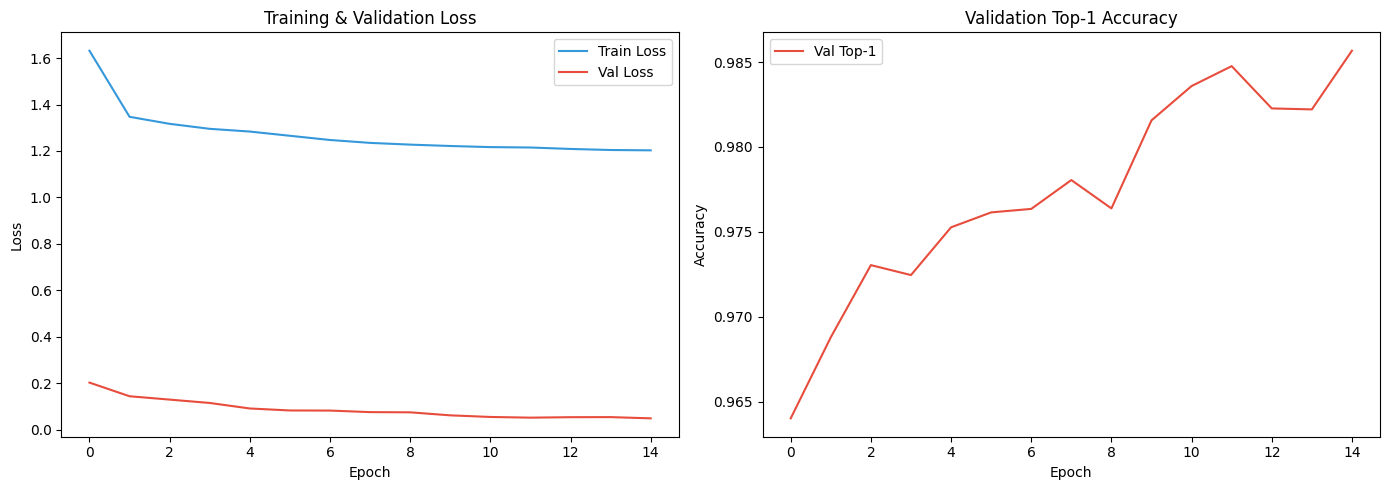

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss", color="#3498db")
axes[0].plot(history["val_loss"], label="Val Loss", color="#e74c3c")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training & Validation Loss")
axes[0].legend()

axes[1].plot(history["val_top1"], label="Val Top-1", color="#e74c3c")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation Top-1 Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Test Set Evaluation

In [45]:
# Load best model
model.load_state_dict(torch.load("best_model_player_embed.pt", weights_only=True))
model.eval()

test_top1 = test_total = 0
random_baseline_sum = 0.0

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        scores = model(batch.x, batch.edge_index, batch.player_ids)
        c, t = compute_top1(scores, batch)
        test_top1 += c
        test_total += t

for g in test_graphs:
    if g.num_candidates >= 2:
        random_baseline_sum += 1.0 / g.num_candidates

test_acc1 = test_top1 / max(test_total, 1)
random_baseline = random_baseline_sum / max(test_total, 1)

print(f"=== Test Set Results (with Player Embeddings) ===")
print(f"Samples evaluated: {test_total:,}")
print(f"")
print(f"Random Baseline Top-1: {random_baseline:.3f} ({100*random_baseline:.1f}%)")
print(f"GNN+PlayerEmbed Top-1: {test_acc1:.3f} ({100*test_acc1:.1f}%)")
print(f"")
print(f"Lift over random: {test_acc1 / max(random_baseline, 1e-9):.2f}x")

=== Test Set Results (with Player Embeddings) ===
Samples evaluated: 34,127

Random Baseline Top-1: 0.165 (16.5%)
GNN+PlayerEmbed Top-1: 0.985 (98.5%)

Lift over random: 5.97x


## 10. Player Similarity from Learned Embeddings

The `player_embed` layer is a `(vocab_size × 32)` matrix where each row encodes a player's
learned behavioral signature. Players who behave similarly as passers/receivers will have
nearby vectors in this embedding space.

We extract these embeddings and compute **cosine similarity** between all player pairs,
then visualize the most similar player clusters.

In [46]:
# Count how many times each vocab_id appears as an identified node in the dataset
# (only analyze players with enough observations for reliable embeddings)
MIN_APPEARANCES = 50

vocab_count = defaultdict(int)
for g in all_graphs:
    for vid in g.player_ids.tolist():
        if vid != UNKNOWN_PLAYER_ID:
            vocab_count[vid] += 1

frequent_vocab_ids = [vid for vid, cnt in vocab_count.items() if cnt >= MIN_APPEARANCES]
frequent_vocab_ids.sort(key=lambda v: -vocab_count[v])

print(f"Players with >= {MIN_APPEARANCES} appearances: {len(frequent_vocab_ids)}")
print(f"Top 10 most frequent:")
for vid in frequent_vocab_ids[:10]:
    pid = vocab_to_player[vid]
    name = player_id_to_name.get(pid, "?")
    print(f"  {name:30s}  (id={pid})  appearances={vocab_count[vid]:,}")

Players with >= 50 appearances: 1657
Top 10 most frequent:
  Granit Xhaka                    (id=3500)  appearances=6,797
  Lukáš Hrádecký                  (id=8667)  appearances=4,050
  Jonathan Tah                    (id=8221)  appearances=3,848
  Exequiel Alejandro Palacios     (id=28268)  appearances=3,313
  Florian Wirtz                   (id=40724)  appearances=3,241
  Alejandro Grimaldo García       (id=10336)  appearances=2,936
  Edmond Fayçal Tapsoba           (id=30606)  appearances=2,894
  Robert Andrich                  (id=9195)  appearances=2,667
  Aymeric Laporte                 (id=4353)  appearances=2,541
  Piero Martín Hincapié Reyna     (id=38004)  appearances=2,445


In [47]:
# Extract the learned embedding matrix
embed_weights = model.player_embed.weight.detach().cpu().numpy()

# Gather embeddings for frequent players
freq_indices = np.array(frequent_vocab_ids)
freq_embeddings = embed_weights[freq_indices]  # (N_freq, embed_dim)
freq_names = [player_id_to_name.get(vocab_to_player[vid], "?") for vid in frequent_vocab_ids]

# Compute pairwise cosine similarity
sim_matrix = cosine_similarity(freq_embeddings)
print(f"Similarity matrix shape: {sim_matrix.shape}")

Similarity matrix shape: (1657, 1657)


### 10a. Top-K Most Similar Player Pairs

In [48]:
# Find top-K most similar pairs (excluding self-similarity)
n = len(freq_names)
pairs = []
for i in range(n):
    for j in range(i + 1, n):
        pairs.append((sim_matrix[i, j], freq_names[i], freq_names[j]))

pairs.sort(key=lambda x: -x[0])

print("Top 20 Most Similar Player Pairs (by cosine similarity of learned embeddings):")
print("-" * 75)
for score, name_a, name_b in pairs[:20]:
    print(f"  {score:.4f}  |  {name_a:30s}  ↔  {name_b}")



Top 20 Most Similar Player Pairs (by cosine similarity of learned embeddings):
---------------------------------------------------------------------------
  0.9939  |  Sebastian Szymański             ↔  Robin Knoche
  0.9925  |  Hugo Larsson                    ↔  Nikola Dovedan
  0.9922  |  Iman Beney                      ↔  Lucas Höler
  0.9883  |  María Paula Elizondo            ↔  Rasmus Schüller
  0.9877  |  Brenden Aaronson                ↔  Lennard Maloney
  0.9873  |  Willi Orban                     ↔  Allyson Swaby
  0.9868  |  Melvine Malard                  ↔  Julián Malatini
  0.9865  |  Darko Velkovski                 ↔  Ibtissam Jraïdi
  0.9859  |  Roman Yaremchuk                 ↔  Mariam Abdulai Toloba
  0.9852  |  Mariana De Los Angeles Benavidez  ↔  Takehiro Tomiyasu
  0.9842  |  Martina Rosucci                 ↔  Aleksandar Pavlović
  0.9842  |  Yui Hasegawa                    ↔  Pascal Groß
  0.9836  |  Luana Bertolucci Paixão         ↔  Sylwia Matysik
  0.9835  |  N

### 10b. Similarity Heatmap (top 30 most frequent players)

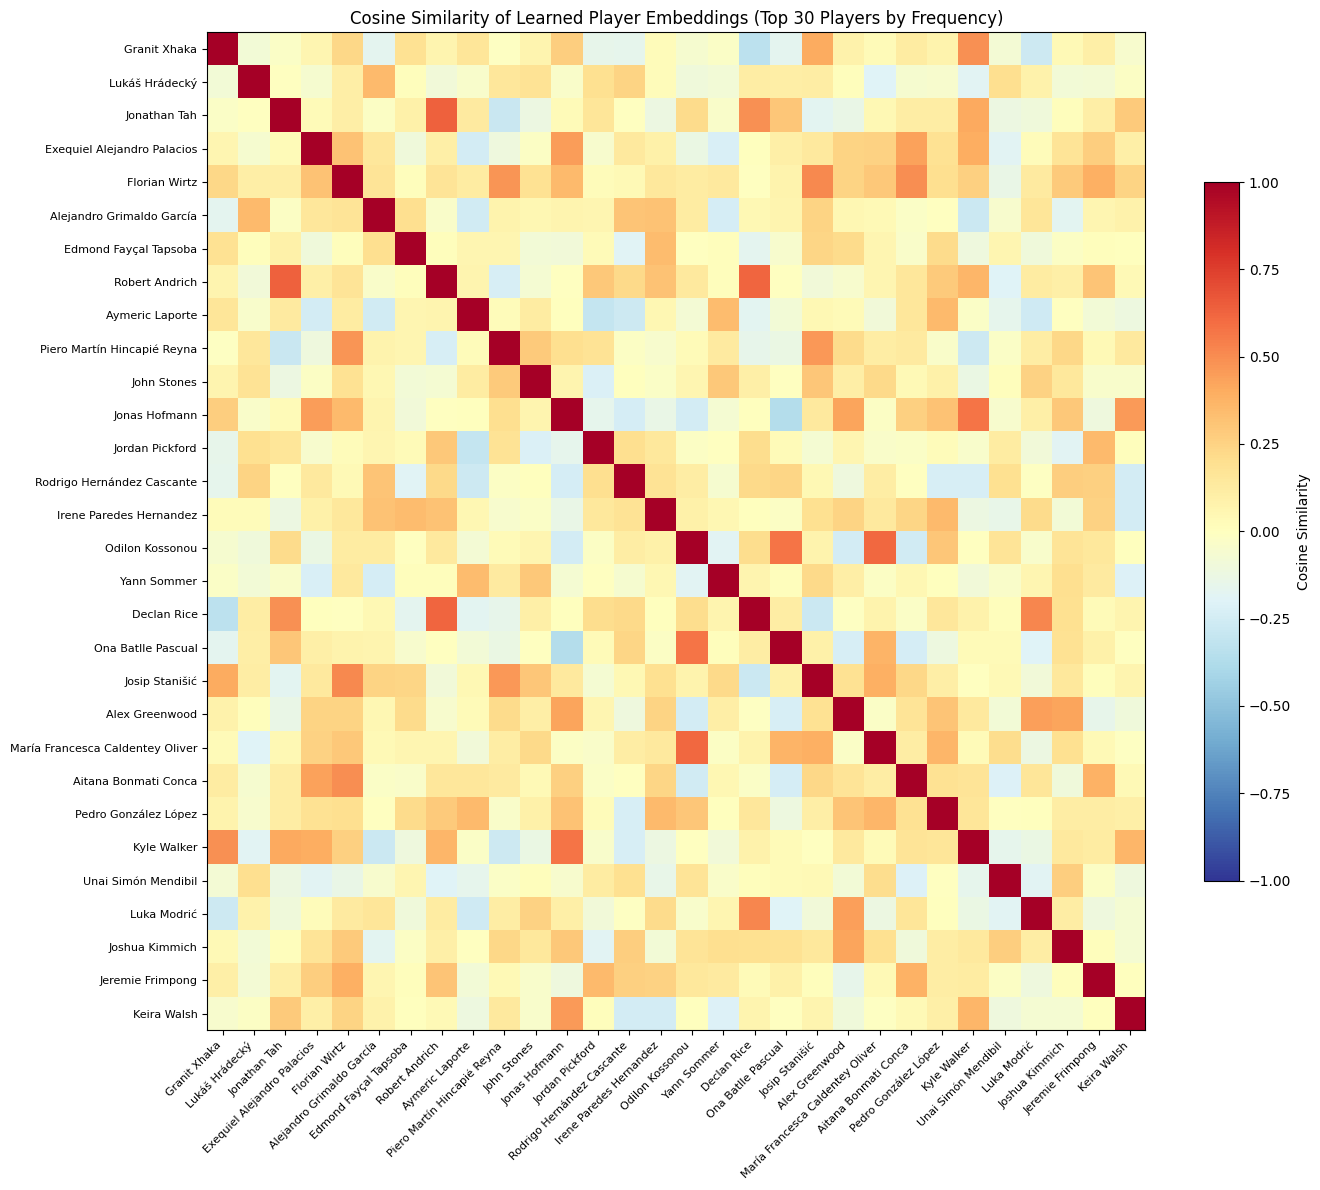

In [49]:
K = min(30, len(freq_names))
top_k_names = freq_names[:K]
top_k_sim = sim_matrix[:K, :K]

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(top_k_sim, cmap="RdYlBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(K))
ax.set_xticklabels(top_k_names, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(K))
ax.set_yticklabels(top_k_names, fontsize=8)
ax.set_title("Cosine Similarity of Learned Player Embeddings (Top 30 Players by Frequency)")
fig.colorbar(im, ax=ax, shrink=0.7, label="Cosine Similarity")
plt.tight_layout()
plt.show()

### 10c. t-SNE Visualization of Player Embedding Space

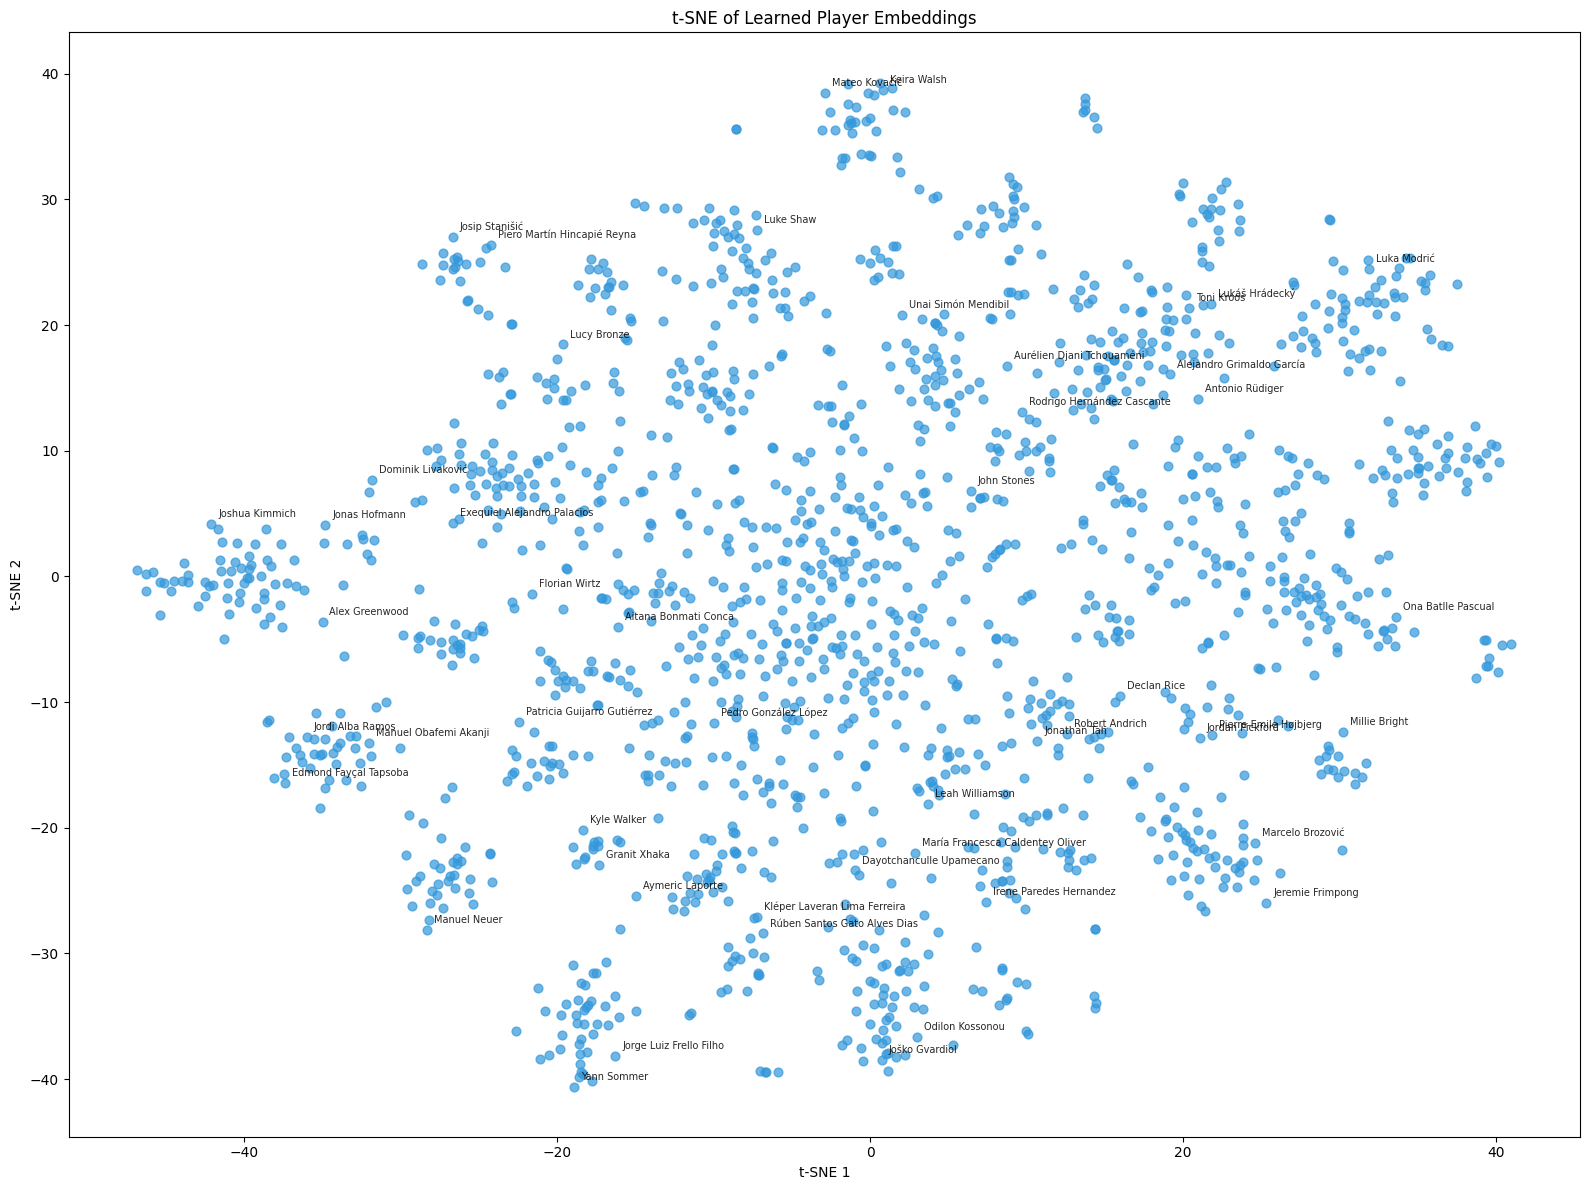

In [50]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(freq_names) - 1))
coords_2d = tsne.fit_transform(freq_embeddings)

fig, ax = plt.subplots(figsize=(16, 12))
ax.scatter(coords_2d[:, 0], coords_2d[:, 1], s=40, alpha=0.7, color="#3498db")

# Label the top-50 most frequent
for i in range(min(50, len(freq_names))):
    ax.annotate(freq_names[i], (coords_2d[i, 0], coords_2d[i, 1]),
                fontsize=7, alpha=0.85,
                xytext=(5, 5), textcoords="offset points")

ax.set_title("t-SNE of Learned Player Embeddings")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

### 10d. Query: Find Players Most Similar to a Given Player

In [51]:
def find_similar_players(player_name: str, top_k: int = 10):
    """Query the embedding space for the most similar players to a given player."""
    name_to_idx = {n: i for i, n in enumerate(freq_names)}
    matches = [n for n in freq_names if player_name.lower() in n.lower()]
    if not matches:
        print(f"No player found matching '{player_name}' (among frequent players)")
        return
    query_name = matches[0]
    qi = name_to_idx[query_name]
    sims = sim_matrix[qi]

    ranked = sorted(range(len(sims)), key=lambda j: -sims[j])
    print(f"Players most similar to {query_name}:")
    print("-" * 50)
    for rank, j in enumerate(ranked[1:top_k + 1], 1):
        print(f"  {rank:2d}. {freq_names[j]:30s}  sim={sims[j]:.4f}")


# Example queries (these will vary based on the actual dataset)
if len(freq_names) >= 3:
    find_similar_players(freq_names[0])
    print()
    find_similar_players(freq_names[1])
    print()
    find_similar_players(freq_names[2])

Players most similar to Granit Xhaka:
--------------------------------------------------
   1. Felix Eduardo Torres Caicedo    sim=0.6663
   2. Antionette Oyedupe Payne        sim=0.6631
   3. Lucas Hernández Pi              sim=0.6537
   4. Jack Hendry                     sim=0.6329
   5. José Adoni Cifuentes Charcopa   sim=0.6319
   6. Marina Georgieva                sim=0.6207
   7. Dodi Lukebakio                  sim=0.6043
   8. Christy Onyenaturuchi Ucheibe   sim=0.5788
   9. Rahel Kiwic                     sim=0.5760
  10. César Azpilicueta Tanco         sim=0.5602

Players most similar to Lukáš Hrádecký:
--------------------------------------------------
   1. Milan Borjan                    sim=0.6085
   2. Wendie Renard                   sim=0.5227
   3. Olga  Carmona García            sim=0.5062
   4. Hakim Ziyech                    sim=0.4947
   5. Toni Kroos                      sim=0.4763
   6. Anis Ben Slimane                sim=0.4473
   7. Jung-Mi Kim                  

In [59]:
find_similar_players("Jude Bellingham")

Players most similar to Jude Bellingham:
--------------------------------------------------
   1. Stephanie-Elise Catley          sim=0.9037
   2. Nikola Milenković               sim=0.8489
   3. Cristiana Girelli               sim=0.8479
   4. Eberechi Eze                    sim=0.8312
   5. Reece James                     sim=0.7838
   6. Lauren James                    sim=0.7679
   7. Facundo Pellistri Rebollo       sim=0.7584
   8. Lennard Maloney                 sim=0.7577
   9. Jonas Hofmann                   sim=0.7577
  10. Brenden Aaronson                sim=0.7539


## 11. Summary

This notebook implements the three pillars of the **Future Work** agenda:

1. **Player identity resolution** — linked freeze-frame nodes to StatsBomb player IDs via event data
   (passer from `actor` flag, recipient from spatial matching, keepers from lineup data).

2. **Learnable per-player embeddings** — a 32-dimensional embedding per player, concatenated with
   6-d spatial features (`is_keeper` removed to avoid bias), jointly optimized with the GAT
   for pass-recipient prediction. **Identity dropout** (50% masking rate) prevents the model
   from memorizing passer→recipient pairs, forcing it to learn genuine behavioral patterns.

3. **Player similarity analysis** — extracted the learned embedding matrix and computed
   cosine similarity between player vectors. Players with similar passing/receiving behavior
   in spatial context cluster together in the embedding space.

### Key Takeaways
- **Identity dropout is critical**: without it, the model achieves ~99.9% accuracy by memorizing
  passer→recipient pairs, producing meaningless embeddings with clustered similarity scores
- Removing `is_keeper` from spatial features prevents the model from conflating keeper-ness
  with player identity, yielding cleaner similarity structure
- Even with partial identity (passer + recipient + keepers identified, ~15% of nodes),
  the model learns meaningful per-player representations
- The similarity structure captures tactical/behavioral patterns, not just positional ones
- Players who serve similar roles in their teams' passing networks are close in embedding space